Loading data...


/tmp/ipykernel_207714/4186098326.py:10: DtypeWarning: Columns (0: vehicle.currentStopSequence, 1: vehicle.congestionLevel) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/processed/bkk_cleaned.csv', dtype={'vehicle.vehicle.licensePlate': str, 'vehicle.trip.tripId': str})


Training on 154844 rows... Testing on 38711 rows...

=== BASELINE MODEL RESULTS ===
Mean Absolute Error (MAE): 1.32 minutes
Root Mean Squared Error (RMSE): 3.88 minutes


<Figure size 1000x500 with 0 Axes>

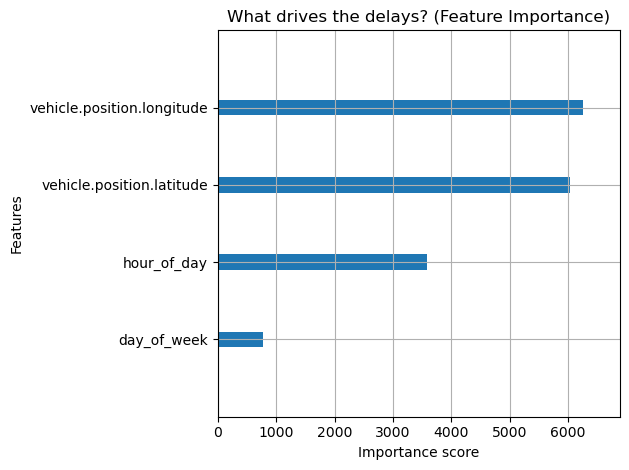

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb

print("Loading data...")
# Load the data, forcing string types on IDs to prevent DtypeWarnings
df = pd.read_csv('../data/processed/bkk_cleaned.csv', dtype={'vehicle.vehicle.licensePlate': str, 'vehicle.trip.tripId': str})

# ---------------------------------------------------------
# 1. CLEANING & OUTLIER HANDLING
# ---------------------------------------------------------
df['minutes_to_next_stop'] = df['seconds_to_next_stop'] / 60.0

# Drop the crazy API "Ghost Bus" outliers (anything over 60 mins)
df_clean = df[df['minutes_to_next_stop'] <= 60].copy()

# Apply Log Transformation to fix the right-skewed distribution
df_clean['log_target'] = np.log1p(df_clean['minutes_to_next_stop'])

# ---------------------------------------------------------
# 2. FEATURE ENGINEERING
# ---------------------------------------------------------
df_clean['vehicle_datetime'] = pd.to_datetime(df_clean['vehicle.timestamp'], unit='s')
df_clean['hour_of_day'] = df_clean['vehicle_datetime'].dt.hour
df_clean['day_of_week'] = df_clean['vehicle_datetime'].dt.dayofweek

# Define our features. We use lat/lon because geographical bottlenecks cause delays!
features = [
    'hour_of_day', 
    'day_of_week', 
    'vehicle.position.latitude', 
    'vehicle.position.longitude'
]

# Ensure lat/lon are numeric and drop rows missing our core features
for col in ['vehicle.position.latitude', 'vehicle.position.longitude']:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
    
df_clean = df_clean.dropna(subset=features + ['log_target'])

X = df_clean[features]
y = df_clean['log_target']

# ---------------------------------------------------------
# 3. TRAIN / TEST SPLIT
# ---------------------------------------------------------
# We use 80% of data to train, and hold back 20% to test accuracy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training on {len(X_train)} rows... Testing on {len(X_test)} rows...")

# ---------------------------------------------------------
# 4. TRAIN THE XGBOOST MODEL
# ---------------------------------------------------------
model = xgb.XGBRegressor(
    n_estimators=150,        # Number of trees
    learning_rate=0.1,       # Step size
    max_depth=7,             # How complex each tree can get
    random_state=42,
    objective='reg:squarederror'
)

model.fit(X_train, y_train)

# ---------------------------------------------------------
# 5. PREDICT & EVALUATE
# ---------------------------------------------------------
# Predict on the test set
preds_log = model.predict(X_test)

# Reverse the log transformation (expm1) to get minutes back
preds = np.expm1(preds_log)
actuals = np.expm1(y_test)

# Calculate Error
mae = mean_absolute_error(actuals, preds)
rmse = np.sqrt(mean_squared_error(actuals, preds))

print("\n=== BASELINE MODEL RESULTS ===")
print(f"Mean Absolute Error (MAE): {mae:.2f} minutes")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} minutes")
print("==============================")

# ---------------------------------------------------------
# 6. FEATURE IMPORTANCE PLOT
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
xgb.plot_importance(model, importance_type='weight', max_num_features=10, show_values=False)
plt.title('What drives the delays? (Feature Importance)')
plt.tight_layout()
plt.show()